# Telco Customer Churn

#### **Context**
Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.

**Churn**, or customer attrition, is the rate at which customers stop doing business with a company, often measured as a percentage of subscribers who cancel or don't renew over a specific time (monthly, quarterly, yearly)

**Objectives:**

- What's the % of Churn Customers and customers that keep in with the active services?
- Is there any patterns in Churn Customers based on the gender?
- Is there any patterns/preference in Churn Customers based on the type of service provided?
- What's the most profitable service types?
- Which features and services are most profitable?

#### **Content**
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes information about:**

- **Customers who left within the last month** – the column is called **Churn**
- **Services that each customer has signed up for** – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- **Customer account information** – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- **Demographic info about customers** – gender, age range, and if they have partners and dependents

## Step 1: Imports packages & dataset

In [1]:
# Import packages

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

In [2]:
# Download dataset from Kagglehub
import kagglehub
import os
from pathlib import Path

dataset_path = Path(
kagglehub.dataset_download("blastchar/telco-customer-churn")
)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Path to csv file
csv_file = next(dataset_path.glob("*.csv"))

In [4]:
# Load dataset into a dataframe
df0 = pd.read_csv(csv_file)

In [5]:
# Set up color palette
pair_palette = sns.color_palette("Paired")
qualitative_palette = sns.color_palette("Set2")

## Step 2. Initial EDA and data cleaning

#### Gather basic information about the data

In [6]:
# Display first few rows of the dataframe
df0.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Basic information about the data
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
# Change datatype of TotalCharges to numeric type
df0['TotalCharges'] = pd.to_numeric(df0['TotalCharges'], errors='coerce')

#### Gather descriptive statistics about the data

In [9]:
df0.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


#### Rename columns

In [10]:
# Rename columns 
df0 = df0.rename(columns = {'customerID' : 'CustomerID',
                            'gender': 'Gender',
                            'tenure': 'Tenure'})

In [11]:
# Display all column names after the update
df0.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

#### Check missing value

In [12]:
# Check missing value 
df0.isna().sum()

CustomerID           0
Gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

There are 11 missing values in the TotalCharges column

In [13]:
# Inspect rows containing missing values
df0[np.isnan(df0['TotalCharges'])]

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Tenure column is 0 for these entries. We can normally drop these rows.

In [14]:
# Drop missing values in TotalCharges column
df0 = df0.dropna(subset = 'TotalCharges')

#### Check duplicates

In [15]:
df0['CustomerID'].duplicated().sum()

np.int64(0)

There are no duplicates values in the data.

#### Check boolean value

In [16]:
df0.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# Column with boolean value
boolean_cols = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'PaperlessBilling']

In [18]:
for col in boolean_cols:
    print(df0[col].value_counts())
    print('-----------------')

Gender
Male      3549
Female    3483
Name: count, dtype: int64
-----------------
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64
-----------------
Partner
No     3639
Yes    3393
Name: count, dtype: int64
-----------------
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
-----------------
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
-----------------
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
-----------------
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
-----------------
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64
-----------------
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64
-----------------
DeviceProtection
No                     3094
Yes                    

Customes who subscribe for Phone Serves can also subscribe for add-on service: MultipleLines

Customers who subscribe for Internet Serves can also subscribe for add-on services: OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, 

#### Check outliers

In [19]:
# Function to create a boxplot to visualize distribution and detect any outliers
def simple_box_plot(df, col):
    plt.figure(figsize = (5,3))
    plt.title(f'Distribution of {col}')
    sns.boxplot(x=df0[col], color = pair_palette[0] )
    plt.show()

In [20]:
# Numeric columns
numeric_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

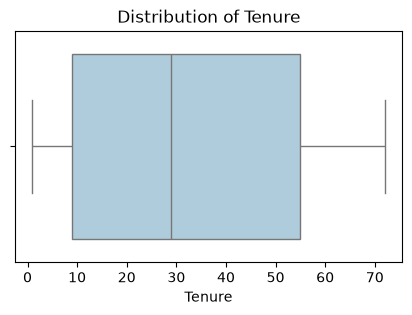

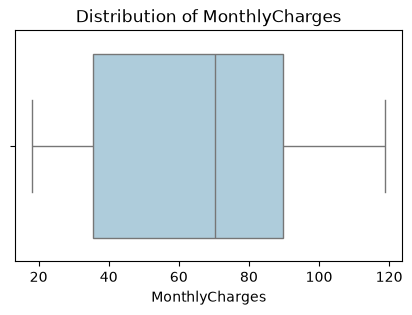

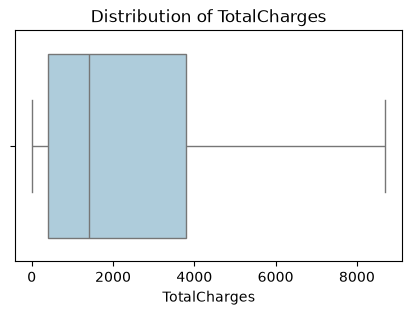

In [21]:
for col in numeric_cols:
    simple_box_plot(df0, col)

## Step 3: Continue EDA & Visualizations

### Churn Rate by Categorical variables

In [22]:
df1 = df0.copy()

#### Customer related variables

In [23]:
# Group Tenure by range
bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49+']

df1['tenure_group'] = pd.cut(
    df0['Tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [24]:
# Function to create charts

def bar_chart_churn_rate(df, variable):

    # Calculate churn rate by group
    churn_rate = (
        df
        .groupby([variable, 'Churn'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    churn_rate['churn_rate'] = churn_rate['Yes'] / (churn_rate['Yes'] + churn_rate['No'])

    # Set up subplots: 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(10,3))

    # Bar chart for Churn Rate
    axes[0].bar(churn_rate[variable], churn_rate['churn_rate'], color = pair_palette[0])
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel('Churn Rate')
    axes[0].set_title(f'Churn Rate by {variable}')
    axes[0].yaxis.set_major_formatter(PercentFormatter(1))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Bar chart for Distribution (count)
    total_count = churn_rate['Yes'] + churn_rate['No']
    axes[1].bar(churn_rate[variable], total_count, color = pair_palette[1])
    axes[1].set_xlabel(variable)
    axes[1].set_ylabel('Number of Customers')
    axes[1].set_title(f'Distribution of {variable}')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Adjust the width space between the subplots
    plt.subplots_adjust(wspace=0.5)

    plt.show()

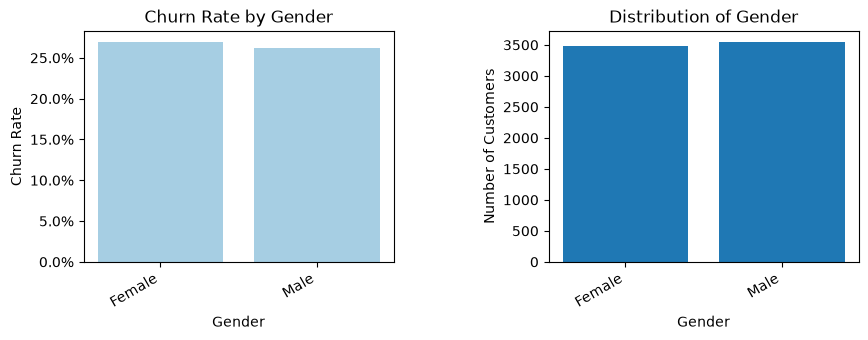

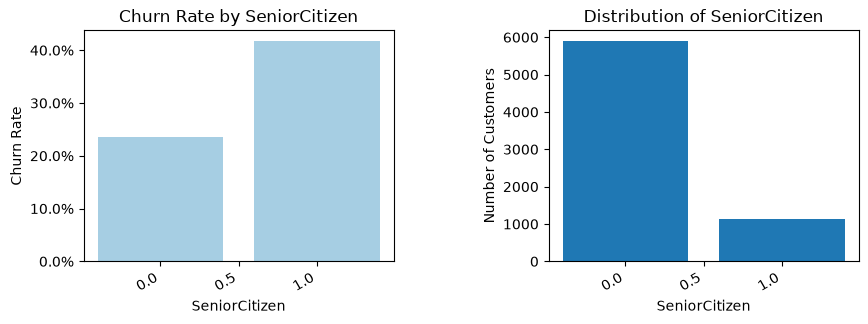

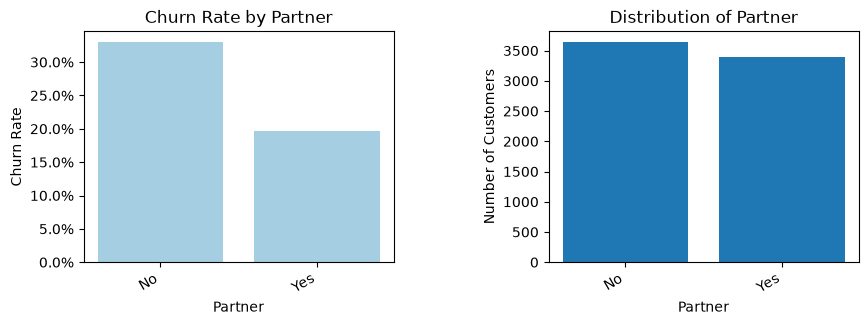

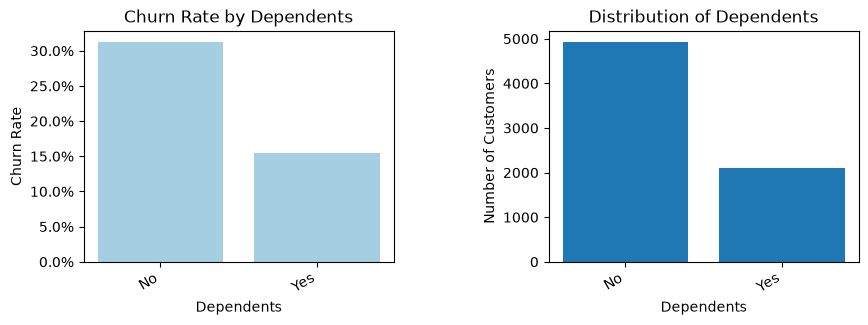

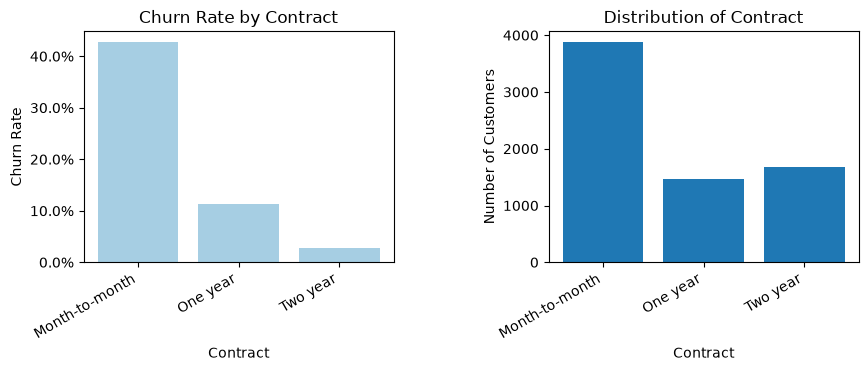

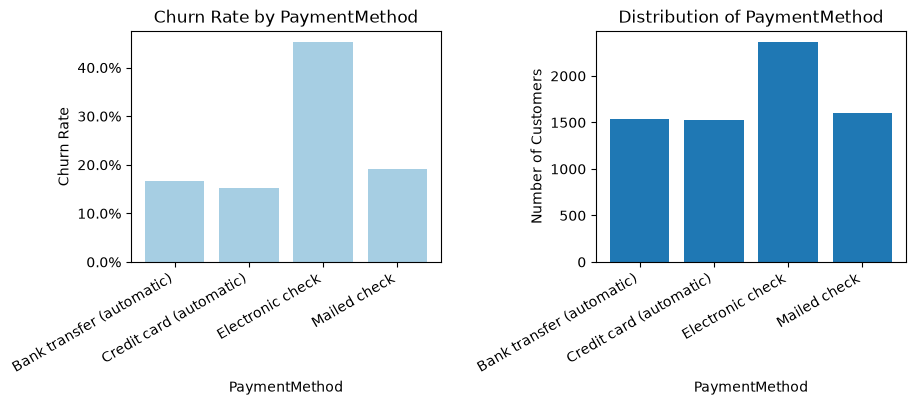

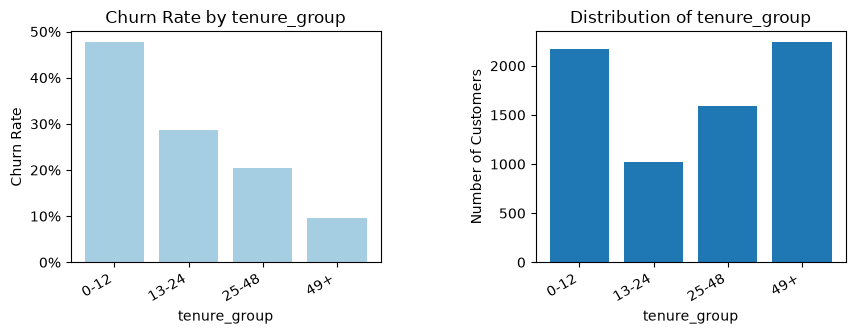

In [25]:
# Column related to customers
customer_col = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'tenure_group']

for col in customer_col:
    bar_chart_churn_rate(df1,col)

##### Some conclusion

**Gender**
- Distribution: Relatively balanced (`~50-50%`) between Female and Male customers
- Churn rate: Nearly identical (`~26-27%`) for both groups

**SeniorCitizen (Age Group)**
- Senior citizens account for only `~16%` of total customers
- Churn rate for seniors `~41%` is approximately `1.7x` higher than non-seniors (`~24%`)

**Partners**
- Distribution: Relatively balanced between customers who have partners and who do not
- Customers without partners have higher churn rate

**Dependents (Family Structure)**
- `~70%` of customers do NOT have dependents
- Customers WITHOUT dependents have `2x` higher churn rate (`~31%` vs `~16%`)

<span style='color:#FF0000'>**Contract (Contract Type)**</span>
- Month-to-month contracts dominate (`~55%` of customers)
- Churn rate decreases dramatically with contract length: `~43%` (MTM) → `~11%` (One year) → `~3%` (Two year)

**Payment Method**
- Electronic check is the most common payment method, while Bank transfer, Credit card and Mailed check are roughly the same
- Electronic check customers also have the highest churn rate, approximately `45%`, while other methods remain lower than `20%`

<span style='color:#FF0000'>**Tenure**</span>
- Customers are concentrated at two extremes: new customers (0-12 months) account for `~32%` and long-term customers (49+ months) represent `~33%` of the customer base
- Mid-tenure customers (13-24 months and 25-48 months) each comprise approximately `15-23%` of customers
- Clear inverse relationship between tenure and churn rate
- New customers (0-12 months): `~48%` churn rate - critically high
- 13-24 months: `~29%` churn rate
- 25-48 months: `~21%` churn rate
- Long-term customers (49+ months): `~10%` churn rate - lowest risk group

**MonthlyCharges**
- Churned customers: Concentrated in `$70-$110` range (high-cost plans)
- Retained customers: Broader distribution with significant presence in `$20-$40` range (low to mid-tier plans)
- No Churn: Median `~$65`, range `$20-$110`, relatively symmetric distribution
- Yes Churn: Median `~$80`, concentrated in `$70-$100` range, shifted significantly higher

**TotalCharges**
- Direct correlation: **TotalCharges = Tenure × MonthlyCharges**
- Churned customers: Heavily concentrated at `$0-$2,000` (low lifetime value)
- Retained customers: Wide distribution extending to `$8,000`, showing sustained customer relationships
- No Churn: Median `~$1,400`, maximum `$8,700`, few outliers
- Yes Churn: Median `~$500`, maximum `$8,000`, multiple high-value outliers present

#### Phone Service related variables

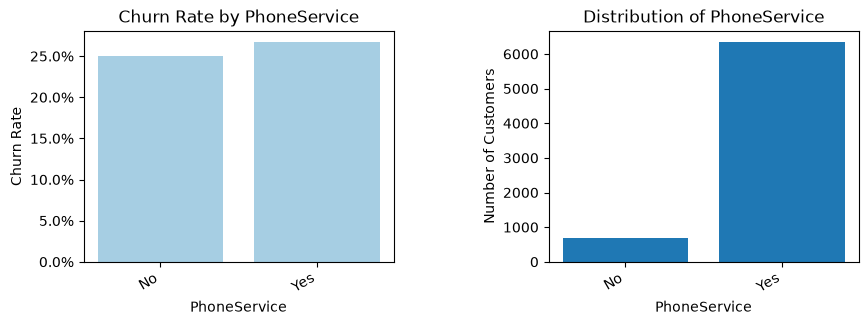

In [26]:
bar_chart_churn_rate(df1, 'PhoneService')

In [27]:
# Create a dataframe for customers with phone service
df_with_phone = df1[df1['PhoneService'] != 'No'].copy()

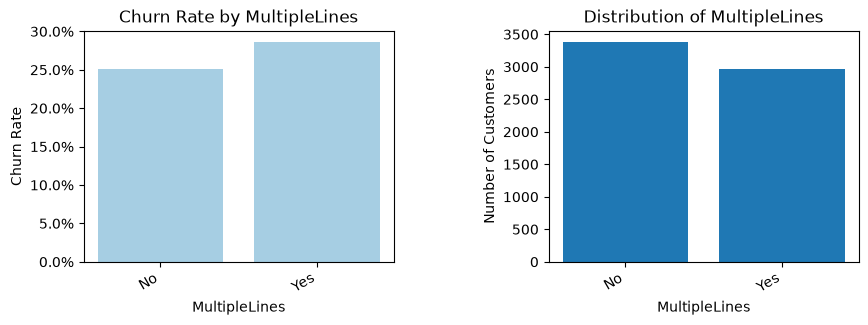

In [28]:
# Columns with Phone add-on services
phone_addon_cols = ['MultipleLines']

for col in phone_addon_cols:
    bar_chart_churn_rate(df_with_phone, col)

#### Internet Service related variables

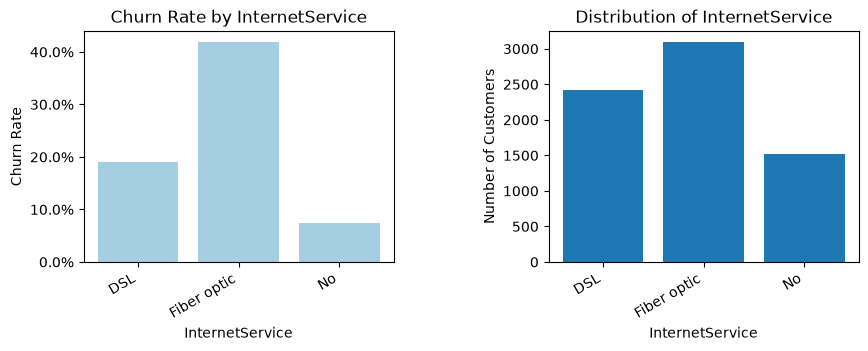

In [29]:
bar_chart_churn_rate(df1, 'InternetService')

In [30]:
# Create a dataframe for customers with internet service
df_with_internet = df1[df1['InternetService'] != 'No'].copy()

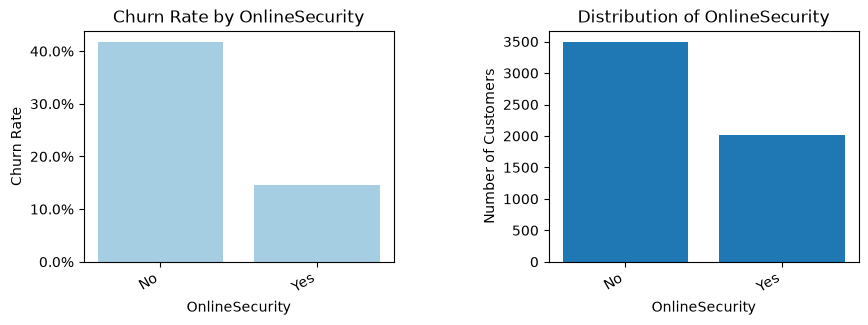

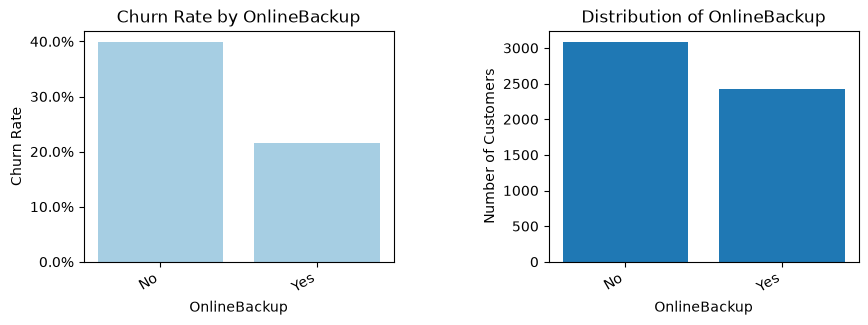

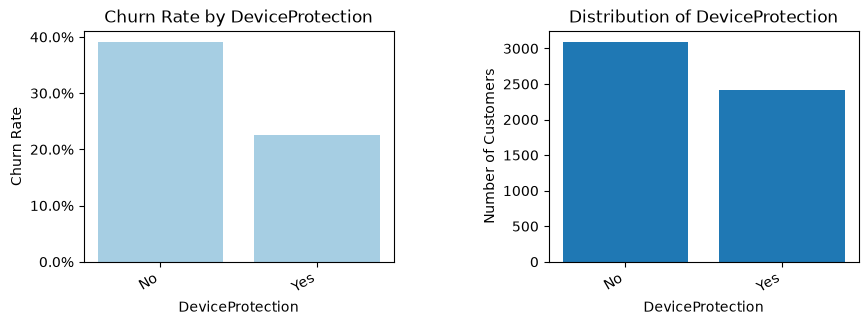

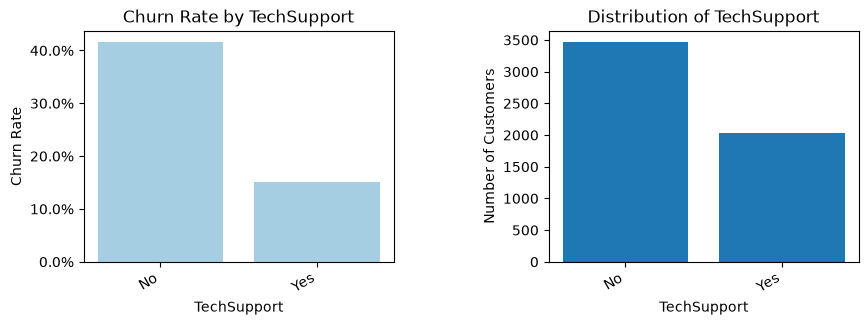

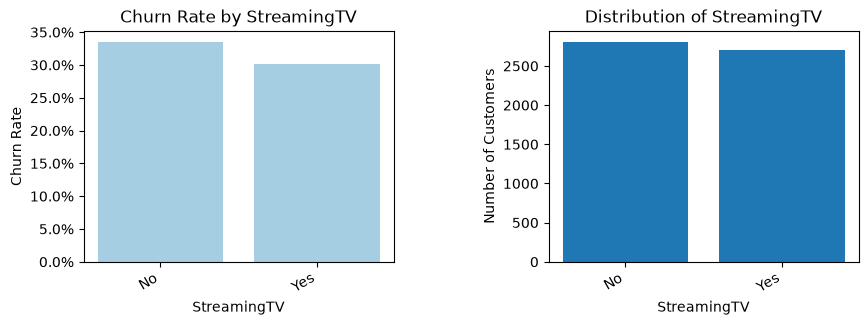

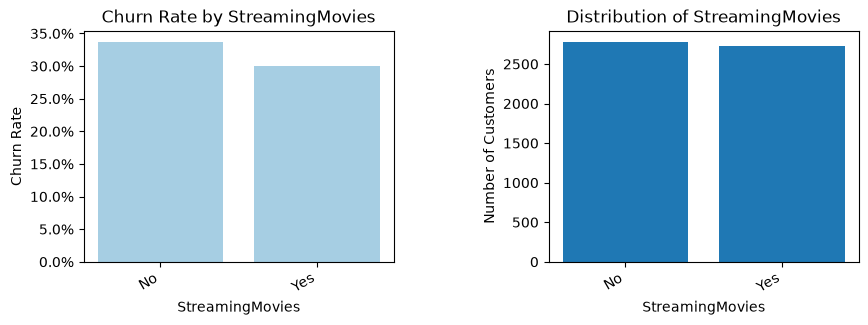

In [31]:
# Columns with Internet add-on services
internet_addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_addon_cols:
    bar_chart_churn_rate(df_with_internet, col)

### Churn vs Non-Churn with Numeric variables

In [32]:
# Function to create histogram, boxplot and density plot for numeric variables
def plot_numerical_analysis(df, col):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram by Churn
    axes[0].hist([df[df['Churn']=='No'][col], df[df['Churn']=='Yes'][col]], 
                 label=['No Churn', 'Churn'], bins=30, alpha=0.7)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Distribution of {col} by Churn')
    axes[0].legend()
    
    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1])
    axes[1].set_title(f'{col} by Churn')
    axes[1].set_xlabel('Churn')
    plt.suptitle('')
    
    # Density plot
    df[df['Churn']=='No'][col].plot(kind='density', ax=axes[2], label='No Churn')
    df[df['Churn']=='Yes'][col].plot(kind='density', ax=axes[2], label='Churn')
    axes[2].set_title(f'Density Plot of {col}')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

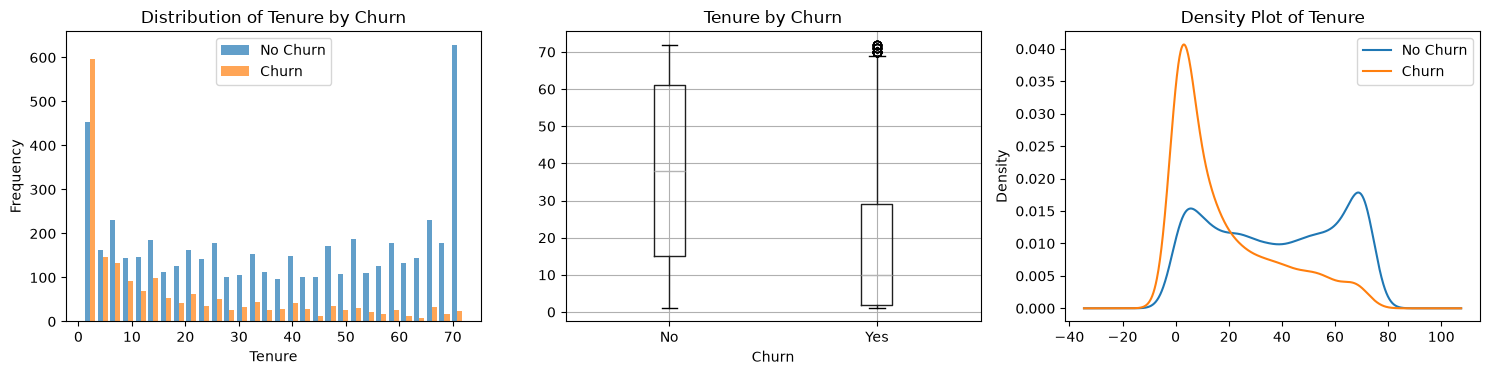

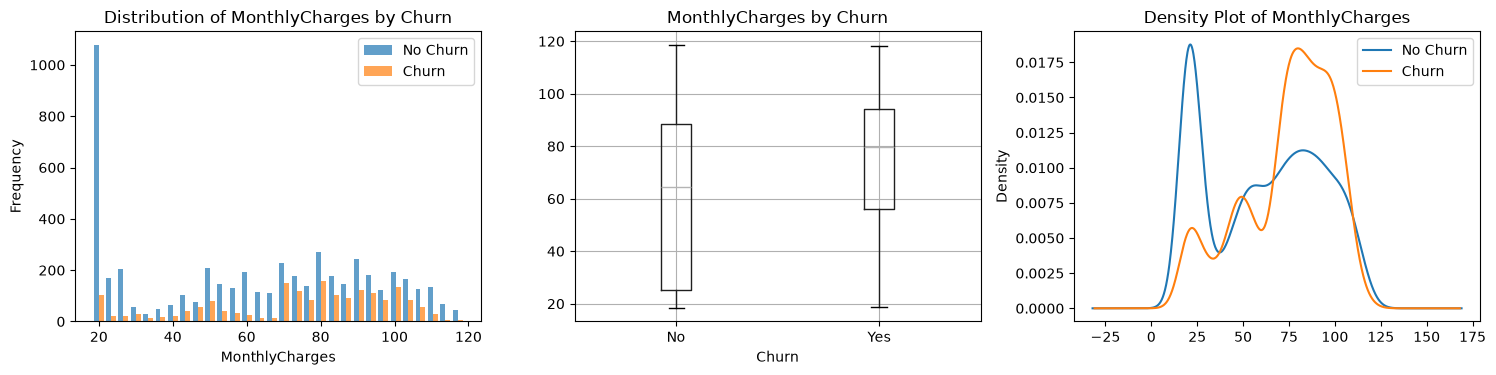

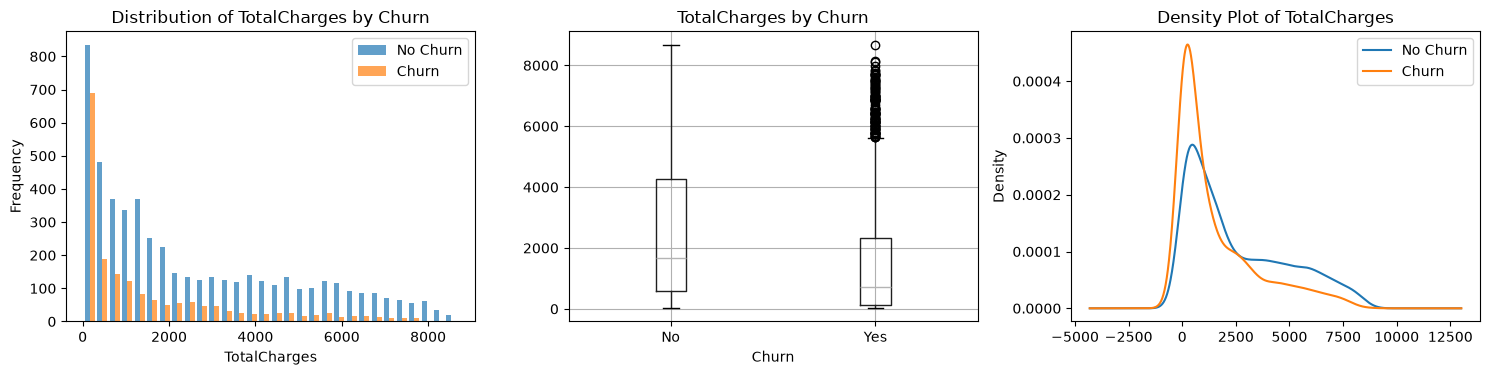

In [33]:
# Create chart
for col in numeric_cols:
    plot_numerical_analysis(df1, col)

##### Some conclusion

**MonthlyCharges**

- Churned customers (orange): Concentrated in `$70-$110` range (high-cost plans)
- Retained customers (blue): Broader distribution with significant presence in `$20-$40` range (low to mid-tier plans)
- No Churn: Median `~$65`, range `$20-$110`, relatively symmetric distribution
- Yes Churn: Median `~$80`, concentrated in `$70-$100` range, shifted significantly higher

**TotalCharges**

- Direct correlation: **TotalCharges = Tenure × MonthlyCharges**
- Churned customers (orange): Heavily concentrated at `$0-$2,000` (low lifetime value)
- Retained customers (blue): Wide distribution extending to `$8,000`, showing sustained customer relationships
- No Churn: Median `~$1,400`, maximum `$8,700`, few outliers
- Yes Churn: Median `~$500`, maximum `$8,000`, multiple high-value outliers present

### Interaction Analysis

In [34]:
# Function to create heatmap between 2 variables

def plot_churn_heatmap(df, col1, col2):

    churn_pivot = df.groupby([col1, col2], observed=True)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x)
    ).unstack()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(churn_pivot, annot=True, fmt='.2%', cmap='Blues', 
                cbar_kws={'label': 'Churn Rate'})
    plt.title(f'Churn Rate: {col1} vs {col2}')
    plt.tight_layout()
    plt.show()


#### Contract vs tenure_group

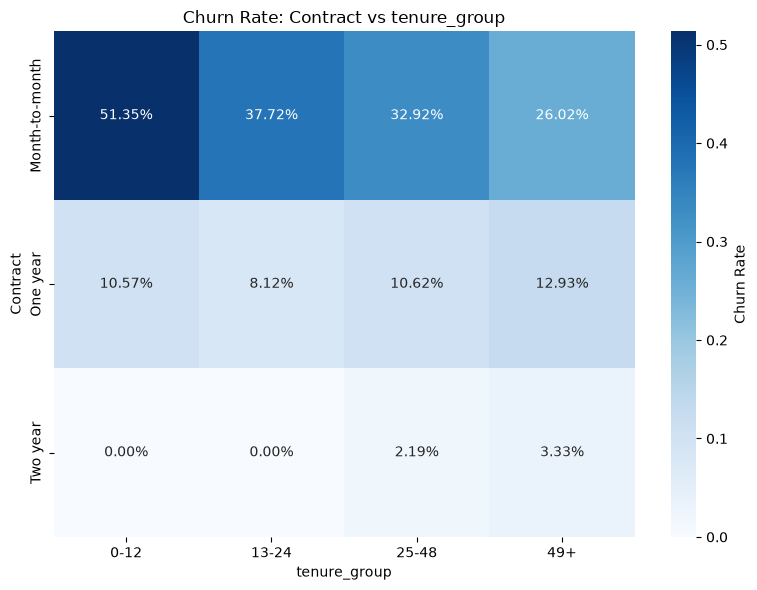

In [35]:
plot_churn_heatmap(df1, 'Contract', 'tenure_group')

**Month-to-month contracts (Highest risk):**
- Churn rate decreases consistently with tenure: `51.35%` → `26.02%`
- However, even long-term MTM customers (`49+` months) maintain a **high** churn rate of `26%` - **8x higher** than Two-year contracts
- **Critical insight**: Month-to-month structure creates perpetual churn risk regardless of tenure

**One-year contracts (Moderate risk):**
- Churn rates range from `8-13%` with a **U-shaped pattern**
- **Lowest churn** at `13-24` months (`8.12%`) - customers who renewed once are most stable
- Churn increases slightly for long-term customers (`49+`: `12.93%`), suggesting some customers remain on One-year intentionally rather than upgrading to Two-year
- **Insight**: The "sweet spot" is customers who have completed and renewed their first One-year contract

**Two-year contracts (Lowest risk):**
- `0-24` months: **0.00%** churn - contract lock-in is highly effective
- `25-48` months: `2.19%` churn 
- `49+` months: `3.33%` churn (slight increase but still minimal)
- **Critical insight**: Two-year contracts eliminate churn during the contract period and maintain extremely low churn rates even for long-tenured customers

## Step 4. Model Building

### 1. Identify the type of prediction task

Predict if a customer churn or not

### 2. Identify the types of models most appropriate for this task

- Logistics Regression Model
- Tree-based Model

### 3. Drop unnecessary columns
- CustomerID
- PaperlessBilling

In [36]:
# Drop columns
df_model = df1.copy()
df_model = df_model.drop(columns=['CustomerID','PaperlessBilling', 'tenure_group'])

### 4. Encode for binary variables

In [37]:
df_model['Gender'] = df_model['Gender'].map({'Female': 1, 'Male': 0})
df_model['Partner'] = df_model['Partner'].map({'Yes': 1, 'No': 0})
df_model['Dependents'] = df_model['Dependents'].map({'Yes': 1, 'No': 0})
df_model['PhoneService'] = df_model['PhoneService'].map({'Yes': 1, 'No': 0})
df_model['MultipleLines'] = df_model['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})
df_model['OnlineSecurity'] = df_model['OnlineSecurity'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_model['OnlineBackup'] = df_model['OnlineBackup'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_model['DeviceProtection'] = df_model['DeviceProtection'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_model['TechSupport'] = df_model['TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_model['StreamingTV'] = df_model['StreamingTV'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_model['StreamingMovies'] = df_model['StreamingMovies'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

### Modeling Approach 1: Logistic Regression Model

### 5. Isolate the outcome variable & Select the features you want to use in your model

In [38]:
# Isolate the outcome variable
y = df_model['Churn']

In [39]:
# Select the features you want to use in your model
X = df_model.drop('Churn', axis=1)

### 6. Split the data into training set and testing set

In [40]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

### 7. One-Hot Encode for categorical variables (>2 categories)

In [41]:
# One-hot Encoding
cat_cols = ['InternetService', 'Contract', 'PaymentMethod']

# Encode for X_train
X_train = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Encode for X_test
X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Make sure that X_train & X_test have the same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### 8. Logistics Regression Modeling

In [42]:
# Scale numeric variables
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [43]:
log_clf_cv = LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000)
cv_auc_scores = cross_val_score(log_clf_cv, X_train, y_train, cv=4, scoring='roc_auc')
print("Mean CV AUC:", cv_auc_scores.mean())

Mean CV AUC: 0.8444169319737501


In [44]:
# Construct a logistic regression model and fit it to the training dataset
log_clf = LogisticRegression(class_weight='balanced',random_state=42, max_iter=500).fit(X_train, y_train)

In [45]:
# Use the logistic regression model to get predictions on the test set
y_pred = log_clf.predict(X_test)

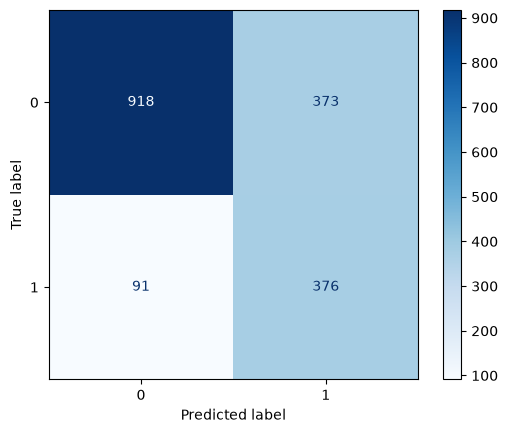

In [46]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_clf.classes_)

# Plot confusion matrix
log_disp.plot(cmap=plt.cm.Blues)

# Display plot
plt.show()

**Confusion Matrix Analysis**

**True Positive (TP) = 376** [1,1]
- Customers who **actually churned** AND model **correctly predicted churn**
- Model caught these churners successfully

**True Negative (TN) = 918** [0,0]
- Customers who **actually stayed** AND model **correctly predicted no-churn**
- Model correctly identified loyal customers

**False Positive (FP) = 373** [0,1]
- Customers who **actually stayed (did NOT churn)** BUT model **incorrectly predicted churn**
- Type I Error - "False Alarm"

**False Negative (FN) = 91** [1,0]
- Customers who **actually churned** BUT model **incorrectly predicted no-churn**
- Type II Error - "Missed Detection"

In [47]:
# Create classification report for logistic regression model
target_names = ['Non-churn', 'Churn']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

   Non-churn       0.91      0.71      0.80      1291
       Churn       0.50      0.81      0.62       467

    accuracy                           0.74      1758
   macro avg       0.71      0.76      0.71      1758
weighted avg       0.80      0.74      0.75      1758



### Modeling Approach 2: Tree-based Model

In [48]:
# Isolate the outcome variable
y = df_model['Churn']

In [49]:
# Select the features you want to use in your model
X = df_model.drop('Churn', axis=1)

In [50]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

### 7. Label Encode for categorical variables (>2 categories)

In [51]:
# Label Encoding
cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

### 8. Tree-based Modeling

#### Round 1: Include all variables as features

**DECISION TREE**

In [52]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

In [53]:
# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6],
             'class_weight': ['balanced']
             }

In [54]:
# Assign scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [55]:
# Instantiate GridSearch
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [56]:
%%time
tree1.fit(X_train, y_train)

CPU times: total: 2.73 s
Wall time: 2.75 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default ch

In [57]:
# Check best parameters & best AUC score on CV
print("Best parameters:", tree1.best_params_)
print("Best AUC score:", tree1.best_score_)

Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best AUC score: 0.8250626088978361


In [58]:
# Predict with test set
y_pred = tree1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1291
           1       0.52      0.74      0.61       467

    accuracy                           0.75      1758
   macro avg       0.71      0.75      0.72      1758
weighted avg       0.79      0.75      0.76      1758



**RANDOM FOREST**

In [59]:
# Instantiate model
rf = RandomForestClassifier(random_state=42, n_jobs =1)

In [60]:
# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             'class_weight': ['balanced']
             }  

In [61]:
# Assign scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [62]:
# Instantiate GridSearch
rf1 = RandomizedSearchCV(
estimator=rf,
param_distributions=cv_params,
n_iter=20, 
scoring='roc_auc',
cv=4,
random_state=42,
verbose=2
)

In [63]:
%%time
rf1.fit(X_train, y_train)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.8s
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.8s
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.8s
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.8s
[CV] END class_weight=balanced, max_depth=3, max_features=1.0, max_samples=0.7, min_samples_leaf=2, min_samples_split=4, n_estimators=300; total time=   0.7s
[CV] END class_weight=balanced, max_depth=3, max_features=1.0, max_samples=0.7, min_samples_leaf=2, min_samples_split=4, n_estimators=300

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected 

In [64]:
# Check best parameters & best AUC score on CV
print("Best parameters:", rf1.best_params_)
print("Best AUC score:", rf1.best_score_)

Best parameters: {'n_estimators': 500, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 1.0, 'max_depth': 5, 'class_weight': 'balanced'}
Best AUC score: 0.8412094376583013


In [65]:
# Predict with test set
y_pred = rf1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1291
           1       0.51      0.80      0.62       467

    accuracy                           0.74      1758
   macro avg       0.71      0.76      0.71      1758
weighted avg       0.80      0.74      0.75      1758



#### Round 2: Incorporate feature engineering to build improved models

### Feature Engineering

In [66]:
df_fe = df_model.copy()

In [67]:
# Create tenure_group
df_fe['tenure_group'] = pd.cut(df_fe['Tenure'], 
                                bins=[0, 12, 24, 48, 72], 
                                labels=['0-1 year', '1-2 years', '2-4 years', '4+ years'])

In [68]:
# Create charge_category
df_fe['charge_category'] = pd.cut(df_fe['MonthlyCharges'], 
                                   bins=[0, 35, 70, 120], 
                                   labels=['Low', 'Medium', 'High'])


In [69]:
# Create num_services
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_fe['num_services'] = df_fe[service_cols].sum(axis=1)

In [70]:
# Drop tenure and other service columns
df_fe = df_fe.drop(columns=['Tenure'] + service_cols)

In [71]:
# Label encode
cat_cols = ['tenure_group', 'charge_category', 'InternetService', 'Contract', 'PaymentMethod']

for col in cat_cols:
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])

In [72]:
# Isolate the outcome variable
y = df_fe['Churn']

In [73]:
# Select the features you want to use in your model
X = df_fe.drop('Churn', axis=1)

In [74]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

**DECISION TREE**

In [75]:
# Instantiate model
fe_tree = DecisionTreeClassifier(random_state=0)

In [76]:
# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6],
             'class_weight': ['balanced']
             }

In [77]:
# Assign scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [78]:
# Instantiate GridSearch
tree2 = GridSearchCV(fe_tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [79]:
%%time
tree2.fit(X_train, y_train)

CPU times: total: 2.59 s
Wall time: 2.6 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default ch

In [80]:
# Check best parameters & best AUC score on CV
print("Best parameters:", tree2.best_params_)
print("Best AUC score:", tree2.best_score_)

Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best AUC score: 0.8197923761844216


In [81]:
# Predict with test set
y_pred = tree2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1291
           1       0.52      0.74      0.61       467

    accuracy                           0.75      1758
   macro avg       0.70      0.75      0.71      1758
weighted avg       0.79      0.75      0.76      1758



**RANDOM FOREST**

In [82]:
# Instantiate model
fe_rf = RandomForestClassifier(random_state=42, n_jobs = 1)

In [83]:
# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             'class_weight': ['balanced']
             }  

In [84]:
# Assign scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [85]:
# Instantiate GridSearch
rf2 = RandomizedSearchCV(
estimator=fe_rf,
param_distributions=cv_params,
n_iter=20, 
scoring='roc_auc', 
cv=4,
random_state=42,
verbose=2
)

In [86]:
%%time
rf2.fit(X_train, y_train)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.4s
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.4s
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.4s
[CV] END class_weight=balanced, max_depth=None, max_features=1.0, max_samples=0.7, min_samples_leaf=1, min_samples_split=4, n_estimators=500; total time=   2.4s
[CV] END class_weight=balanced, max_depth=3, max_features=1.0, max_samples=0.7, min_samples_leaf=2, min_samples_split=4, n_estimators=300; total time=   0.6s
[CV] END class_weight=balanced, max_depth=3, max_features=1.0, max_samples=0.7, min_samples_leaf=2, min_samples_split=4, n_estimators=300

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected 

In [87]:
# Check best parameters & best AUC score on CV
print("Best parameters:", rf2.best_params_)
print("Best AUC score:", rf2.best_score_)

Best parameters: {'n_estimators': 500, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 1.0, 'max_depth': 5, 'class_weight': 'balanced'}
Best AUC score: 0.8386931282101737


In [88]:
# Predict with test set
y_pred = rf2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1291
           1       0.51      0.81      0.62       467

    accuracy                           0.74      1758
   macro avg       0.71      0.76      0.71      1758
weighted avg       0.80      0.74      0.75      1758

